In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [8]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [9]:
# removing Virginica
df = df[df['target'] != 2]
X = df[['petal length (cm)', 'petal width (cm)']].to_numpy()
y = df['target'].to_numpy()
y[y == 0] = -1

In [10]:
X, y

(array([[1.4, 0.2],
        [1.4, 0.2],
        [1.3, 0.2],
        [1.5, 0.2],
        [1.4, 0.2],
        [1.7, 0.4],
        [1.4, 0.3],
        [1.5, 0.2],
        [1.4, 0.2],
        [1.5, 0.1],
        [1.5, 0.2],
        [1.6, 0.2],
        [1.4, 0.1],
        [1.1, 0.1],
        [1.2, 0.2],
        [1.5, 0.4],
        [1.3, 0.4],
        [1.4, 0.3],
        [1.7, 0.3],
        [1.5, 0.3],
        [1.7, 0.2],
        [1.5, 0.4],
        [1. , 0.2],
        [1.7, 0.5],
        [1.9, 0.2],
        [1.6, 0.2],
        [1.6, 0.4],
        [1.5, 0.2],
        [1.4, 0.2],
        [1.6, 0.2],
        [1.6, 0.2],
        [1.5, 0.4],
        [1.5, 0.1],
        [1.4, 0.2],
        [1.5, 0.2],
        [1.2, 0.2],
        [1.3, 0.2],
        [1.4, 0.1],
        [1.3, 0.2],
        [1.5, 0.2],
        [1.3, 0.3],
        [1.3, 0.3],
        [1.3, 0.2],
        [1.6, 0.6],
        [1.9, 0.4],
        [1.4, 0.3],
        [1.6, 0.2],
        [1.4, 0.2],
        [1.5, 0.2],
        [1.4, 0.2],


In [11]:
X_normalized = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
X_normalized[:10]

array([[0.09756098, 0.05882353],
       [0.09756098, 0.05882353],
       [0.07317073, 0.05882353],
       [0.12195122, 0.05882353],
       [0.09756098, 0.05882353],
       [0.17073171, 0.17647059],
       [0.09756098, 0.11764706],
       [0.12195122, 0.05882353],
       [0.09756098, 0.05882353],
       [0.12195122, 0.        ]])

In [18]:
print(len(y[y == -1]), len(y[y == 1]))

50 50


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.3, random_state=42)

In [13]:
class Adaline:
    def __init__(self, input_dimension, learning_rate=0.01, epochs=50):
        self.input_dimension = input_dimension
        self.alpha = learning_rate
        self.epochs = epochs

        self.weights = np.random.rand(input_dimension) * 0.1
        self.bias = np.random.rand() * 0.1

        self.losses = []
        self.accuracies = []
        self.weights_history = []

    def activation(self, z):
        return z

    def fit(self, X, y, verbose=False):
        n_samples = X.shape[0]

        for epoch in range(self.epochs):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred = self.activation(linear_output)

            errors = y - y_pred
            self.weights += self.alpha * np.dot(X.T, errors) / n_samples
            self.bias += self.alpha * np.mean(errors)

            self.weights_history.append((self.weights.copy(), self.bias))

            mse = np.mean(errors**2)
            self.losses.append(mse)

            y_pred_class = np.where(y_pred >= 0, 1, -1)
            accuracy = np.mean(y_pred_class == y) * 100
            self.accuracies.append(accuracy)

            if verbose:
                print(f"Epoch {epoch + 1}/{self.epochs}, Loss: {mse:.4f}, Accuracy: {accuracy:.2f}%")

    def predict(self, X):
        return np.where(self.activation(np.dot(X, self.weights) + self.bias) >= 0, 1, -1)


In [52]:
def plot_decision_boundary(model, X_train, y_train, X_test, y_test, title="Decision Boundary"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    x_min_train, x_max_train = X_train[:, 0].min() - 2, X_train[:, 0].max() + 2
    y_min_train, y_max_train = X_train[:, 1].min() - 2, X_train[:, 1].max() + 2
    x_values_train = np.linspace(x_min_train, x_max_train, 100)

    if abs(model.weights[1]) > 1e-6:
        y_values_train = -(model.weights[0] * x_values_train + model.bias) / model.weights[1]
    else:
        y_values_train = np.full_like(x_values_train, -model.bias / (model.weights[0] + 1e-6))

    ax1.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color="blue", label="Setosa (-1)", alpha=0.2)
    ax1.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color="red", label="Versicolor (1)", alpha=0.2)
    ax1.plot(x_values_train, y_values_train, "k-", linewidth=2, label="Decision Boundary")

    ax1.set_xlabel("Petal Length (Normalized)")
    ax1.set_ylabel("Petal Width (Normalized)")
    ax1.set_title(f"{title} - Training Data")
    ax1.legend()
    ax1.set_xlim(x_min_train, x_max_train)
    ax1.set_ylim(y_min_train, y_max_train)

    x_min_test, x_max_test = X_test[:, 0].min() - 2, X_test[:, 0].max() + 2
    y_min_test, y_max_test = X_test[:, 1].min() - 2, X_test[:, 1].max() + 2
    x_values_test = np.linspace(x_min_test, x_max_test, 100)

    if abs(model.weights[1]) > 1e-6:
        y_values_test = -(model.weights[0] * x_values_test + model.bias) / model.weights[1]
    else:
        y_values_test = np.full_like(x_values_test, -model.bias / (model.weights[0] + 1e-6))

    ax2.scatter(X_test[y_test == -1][:, 0], X_test[y_test == -1][:, 1], color="blue", label="Setosa (-1)", alpha=0.2)
    ax2.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color="red", label="Versicolor (1)", alpha=0.2)
    ax2.plot(x_values_test, y_values_test, "k-", linewidth=2, label="Decision Boundary")

    ax2.set_xlabel("Petal Length (Normalized)")
    ax2.set_ylabel("Petal Width (Normalized)")
    ax2.set_title(f"{title} - Test Data")
    ax2.legend()
    ax2.set_xlim(x_min_test, x_max_test)
    ax2.set_ylim(y_min_test, y_max_test)

    # plt.show()

def plot_loss_over_epochs(model, title="Loss Over Epochs"):
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, model.epochs + 1), model.losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title(title)
    plt.show()

def plot_accuracies_over_epochs(model, title="Accuracies Over Epochs"):
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, model.epochs + 1), model.accuracies)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.show()

def plot_loss_and_accuracy(model):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(range(1, model.epochs + 1), model.losses)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss (MSE)")
    ax1.set_title("Loss Over Epochs")

    ax2.plot(range(1, model.epochs + 1), model.accuracies)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Accuracies Over Epochs")

    # plt.show()

def plot_decision_boundary_and_loss_accuracy(model, X_train, y_train, X_test, y_test, title="Decision Boundary and Loss/Accuracy"):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    ax1 = axes[0, 0]
    x_min_train, x_max_train = X_train[:, 0].min() - 2, X_train[:, 0].max() + 2
    y_min_train, y_max_train = X_train[:, 1].min() - 2, X_train[:, 1].max() + 2
    x_values_train = np.linspace(x_min_train, x_max_train, 100)

    if abs(model.weights[1]) > 1e-6:
        y_values_train = -(model.weights[0] * x_values_train + model.bias) / model.weights[1]
    else:
        y_values_train = np.full_like(x_values_train, -model.bias / (model.weights[0] + 1e-6))

    ax1.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color="blue", label="Setosa (-1)", alpha=0.2)
    ax1.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color="red", label="Versicolor (1)", alpha=0.2)
    ax1.plot(x_values_train, y_values_train, "k-", linewidth=2, label="Decision Boundary")

    ax1.set_xlabel("Petal Length (Normalized)")
    ax1.set_ylabel("Petal Width (Normalized)")
    ax1.set_title(f"{title} - Training Data")
    ax1.legend()
    ax1.set_xlim(x_min_train, x_max_train)
    ax1.set_ylim(y_min_train, y_max_train)

    ax2 = axes[0, 1]
    x_min_test, x_max_test = X_test[:, 0].min() - 2, X_test[:, 0].max() + 2
    y_min_test, y_max_test = X_test[:, 1].min() - 2, X_test[:, 1].max() + 2
    x_values_test = np.linspace(x_min_test, x_max_test, 100)

    if abs(model.weights[1]) > 1e-6:
        y_values_test = -(model.weights[0] * x_values_test + model.bias) / model.weights[1]
    else:
        y_values_test = np.full_like(x_values_test, -model.bias / (model.weights[0] + 1e-6))

    ax2.scatter(X_test[y_test == -1][:, 0], X_test[y_test == -1][:, 1], color="blue", label="Setosa (-1)", alpha=0.2)
    ax2.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color="red", label="Versicolor (1)", alpha=0.2)
    ax2.plot(x_values_test, y_values_test, "k-", linewidth=2, label="Decision Boundary")

    ax2.set_xlabel("Petal Length (Normalized)")
    ax2.set_ylabel("Petal Width (Normalized)")
    ax2.set_title(f"{title} - Test Data")
    ax2.legend()
    ax2.set_xlim(x_min_test, x_max_test)
    ax2.set_ylim(y_min_test, y_max_test)

    ax3 = axes[1, 0]
    ax3.plot(range(1, model.epochs + 1), model.losses)
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("Loss (MSE)")
    ax3.set_title("Loss Over Epochs")

    ax4 = axes[1, 1]
    ax4.plot(range(1, model.epochs + 1), model.accuracies)
    ax4.set_xlabel("Epoch")
    ax4.set_ylabel("Accuracy (%)")
    ax4.set_title("Accuracies Over Epochs")

    plt.tight_layout()
    plt.show()

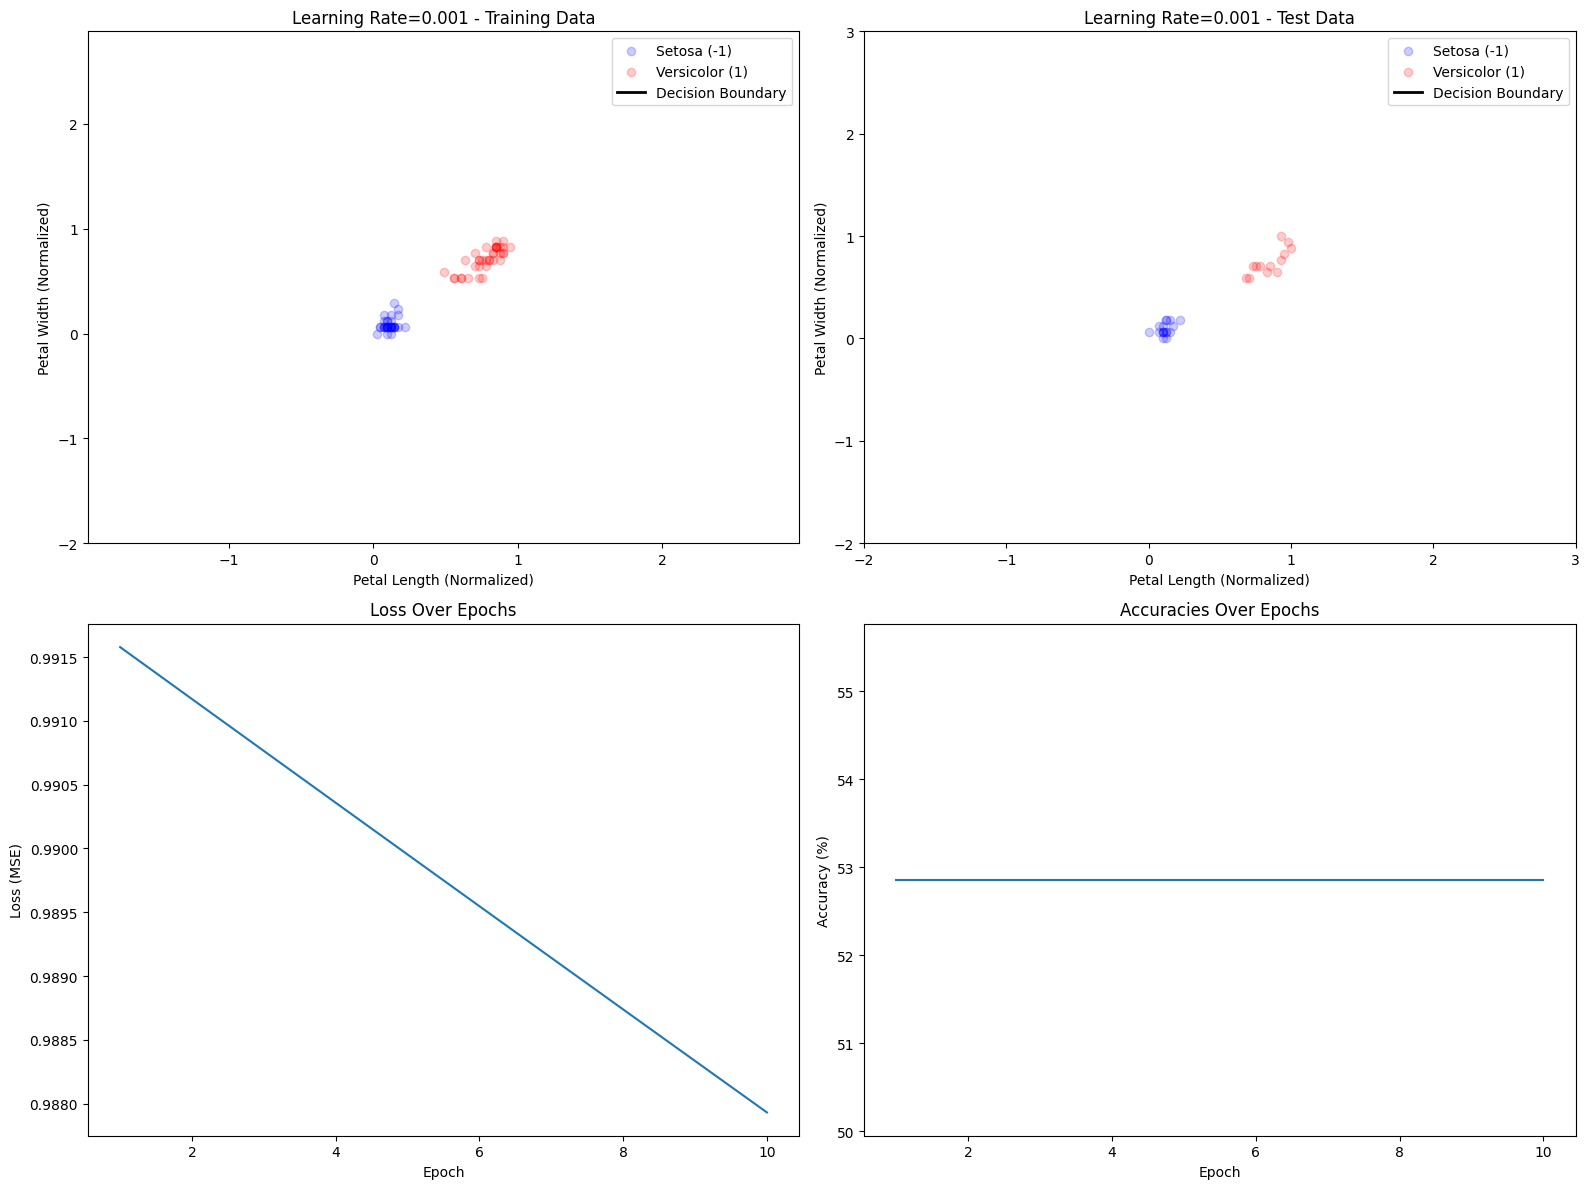

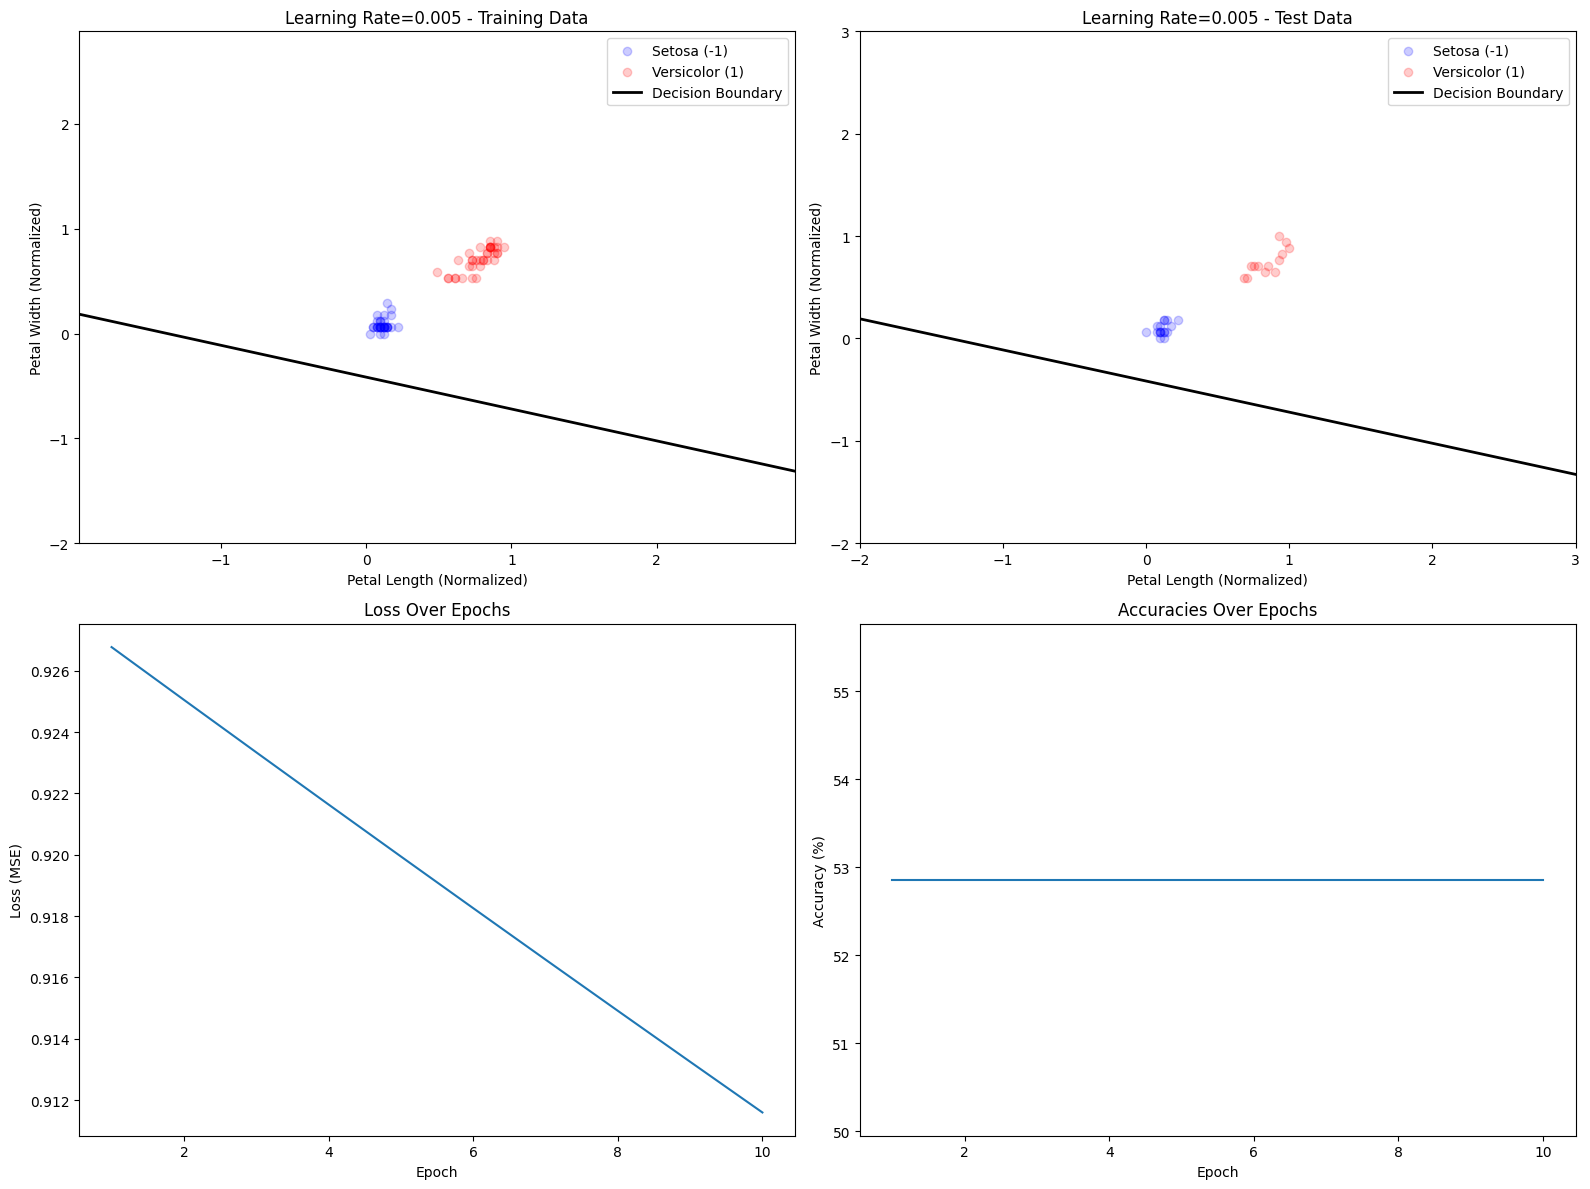

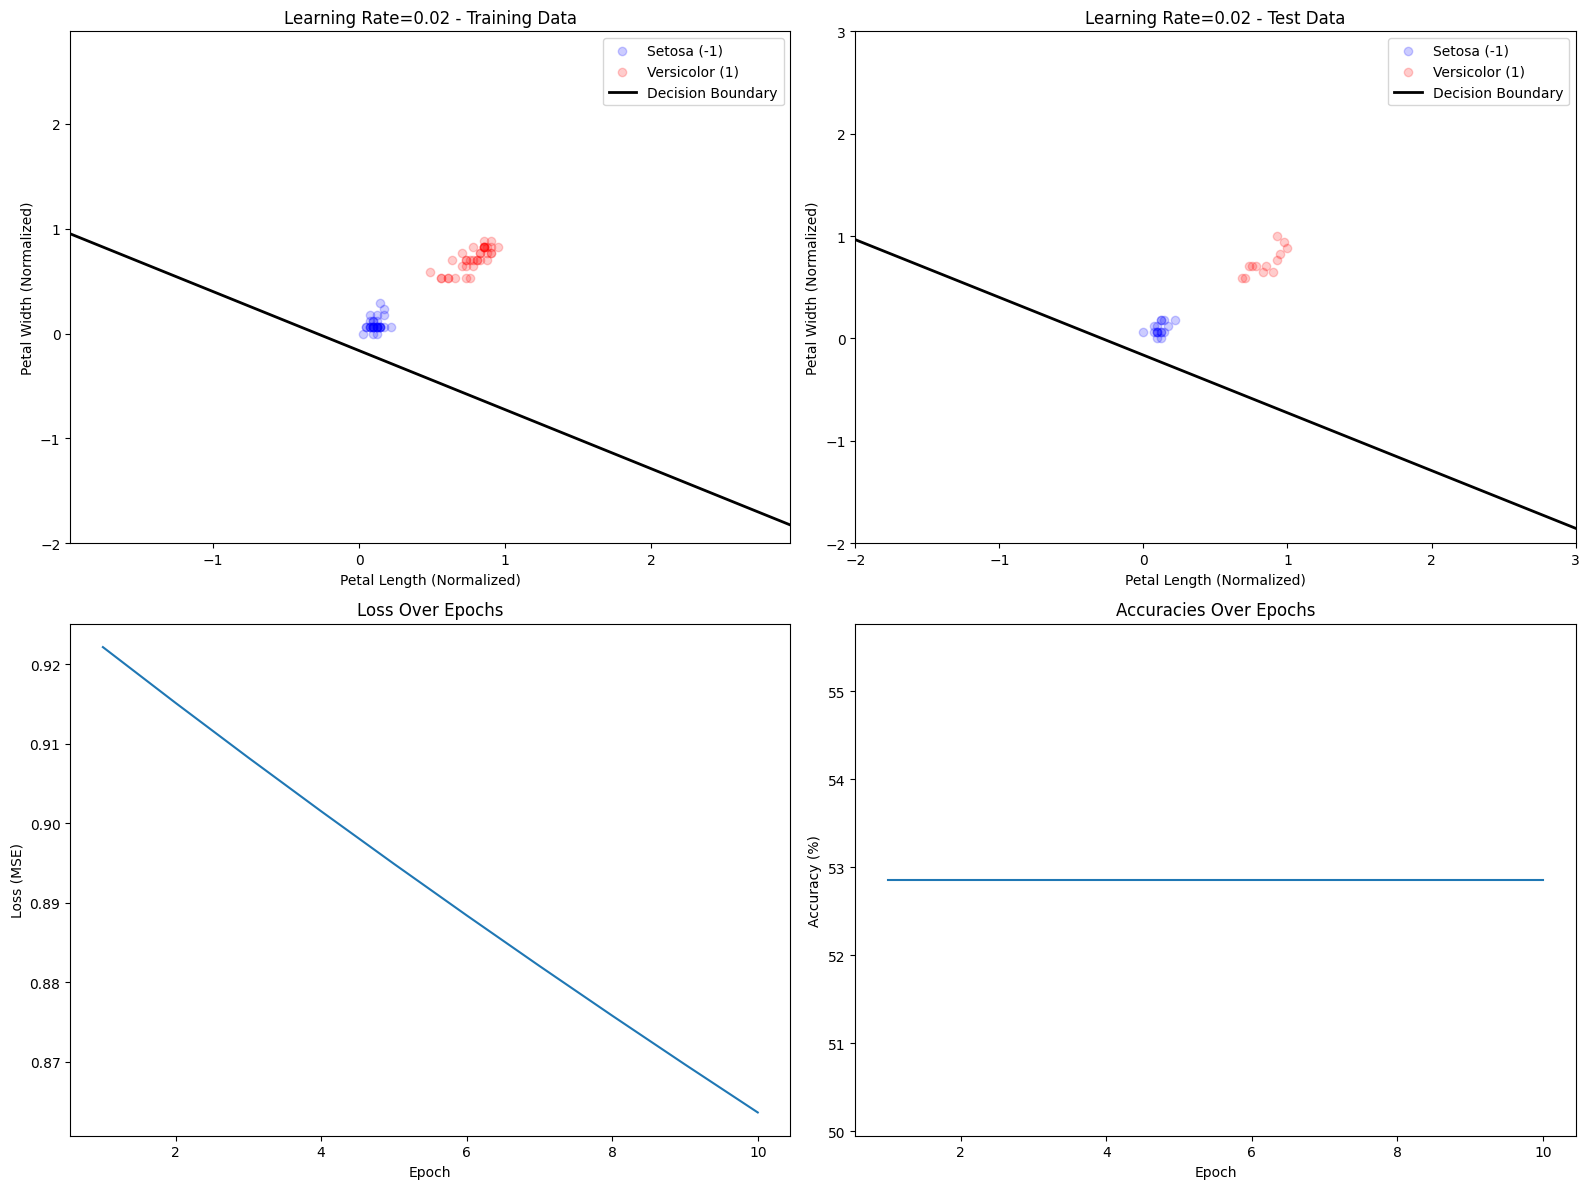

In [53]:
models = dict()
learning_rates = [0.001, 0.005, 0.02]
epochs = 10

for lr in learning_rates:
    model = Adaline(2, lr, epochs)
    model.fit(X_train, y_train)
    models[lr] = model

# plt.figure(figsize=(16, 6*6))
for lr, model in models.items():
    plot_decision_boundary_and_loss_accuracy(model, X_train, y_train, X_test, y_test, title=f'Learning Rate={lr}')
# plt.show()

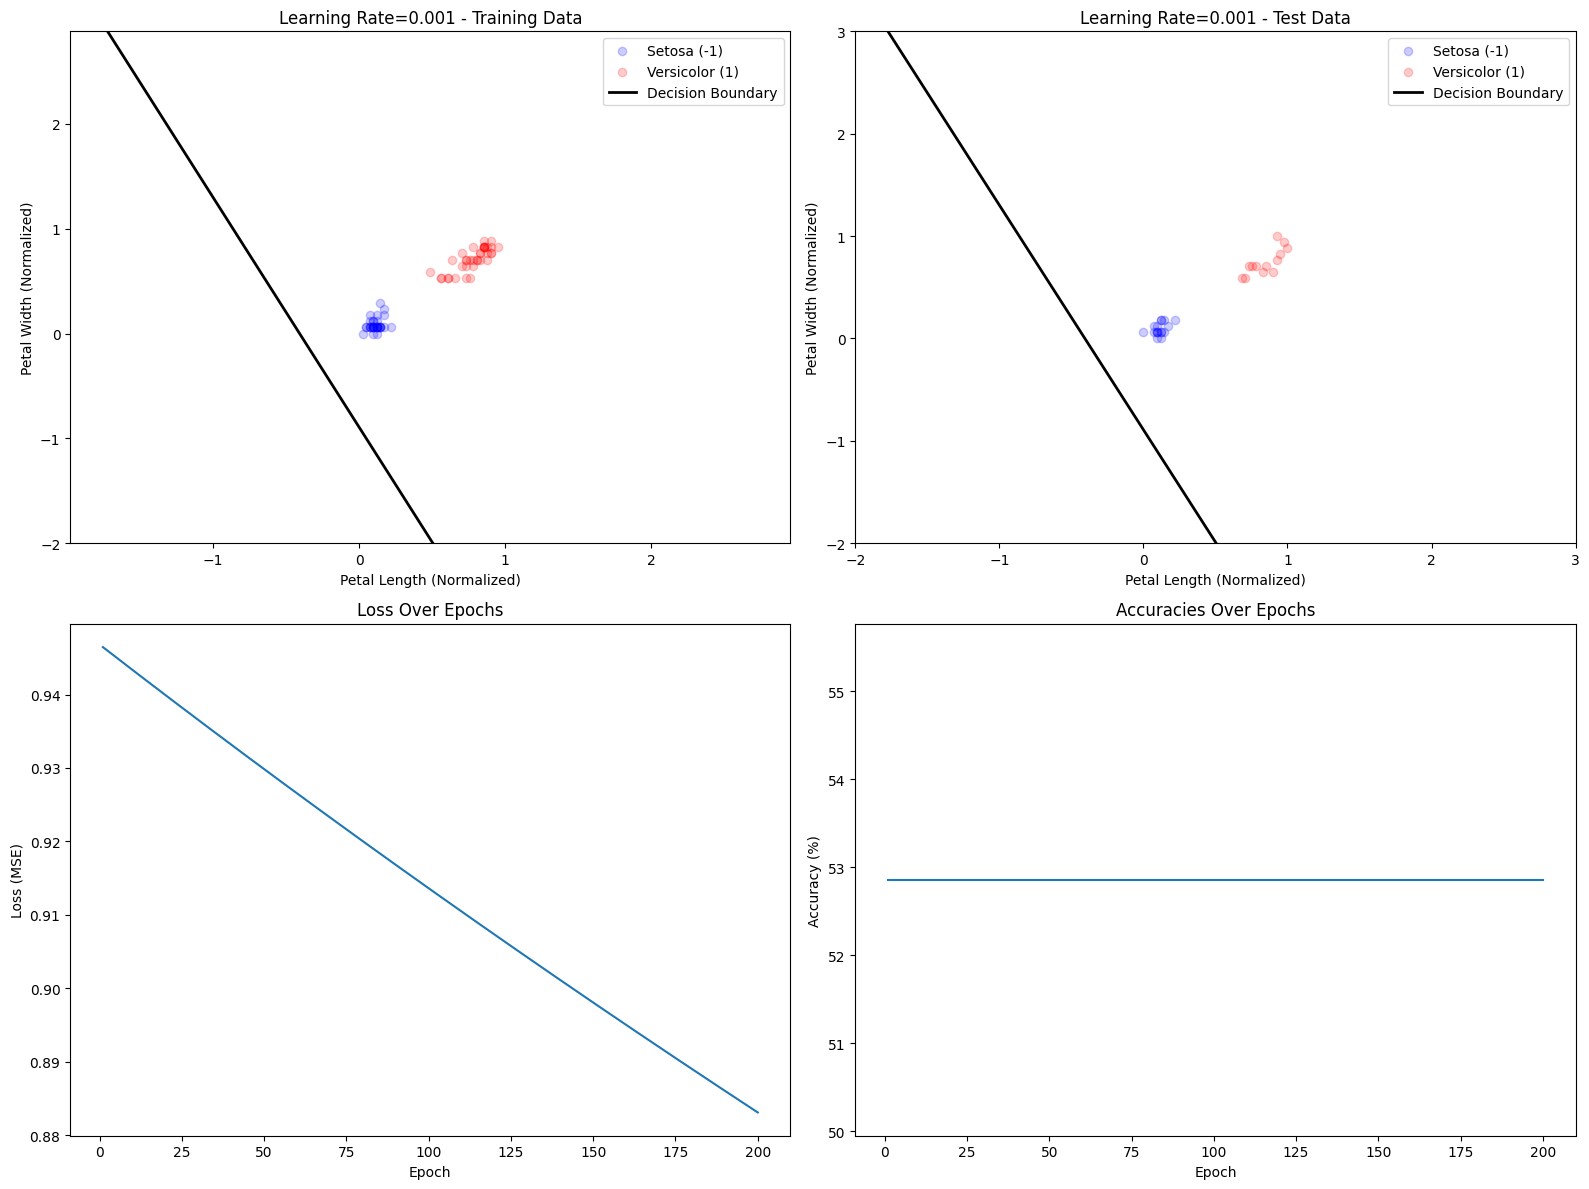

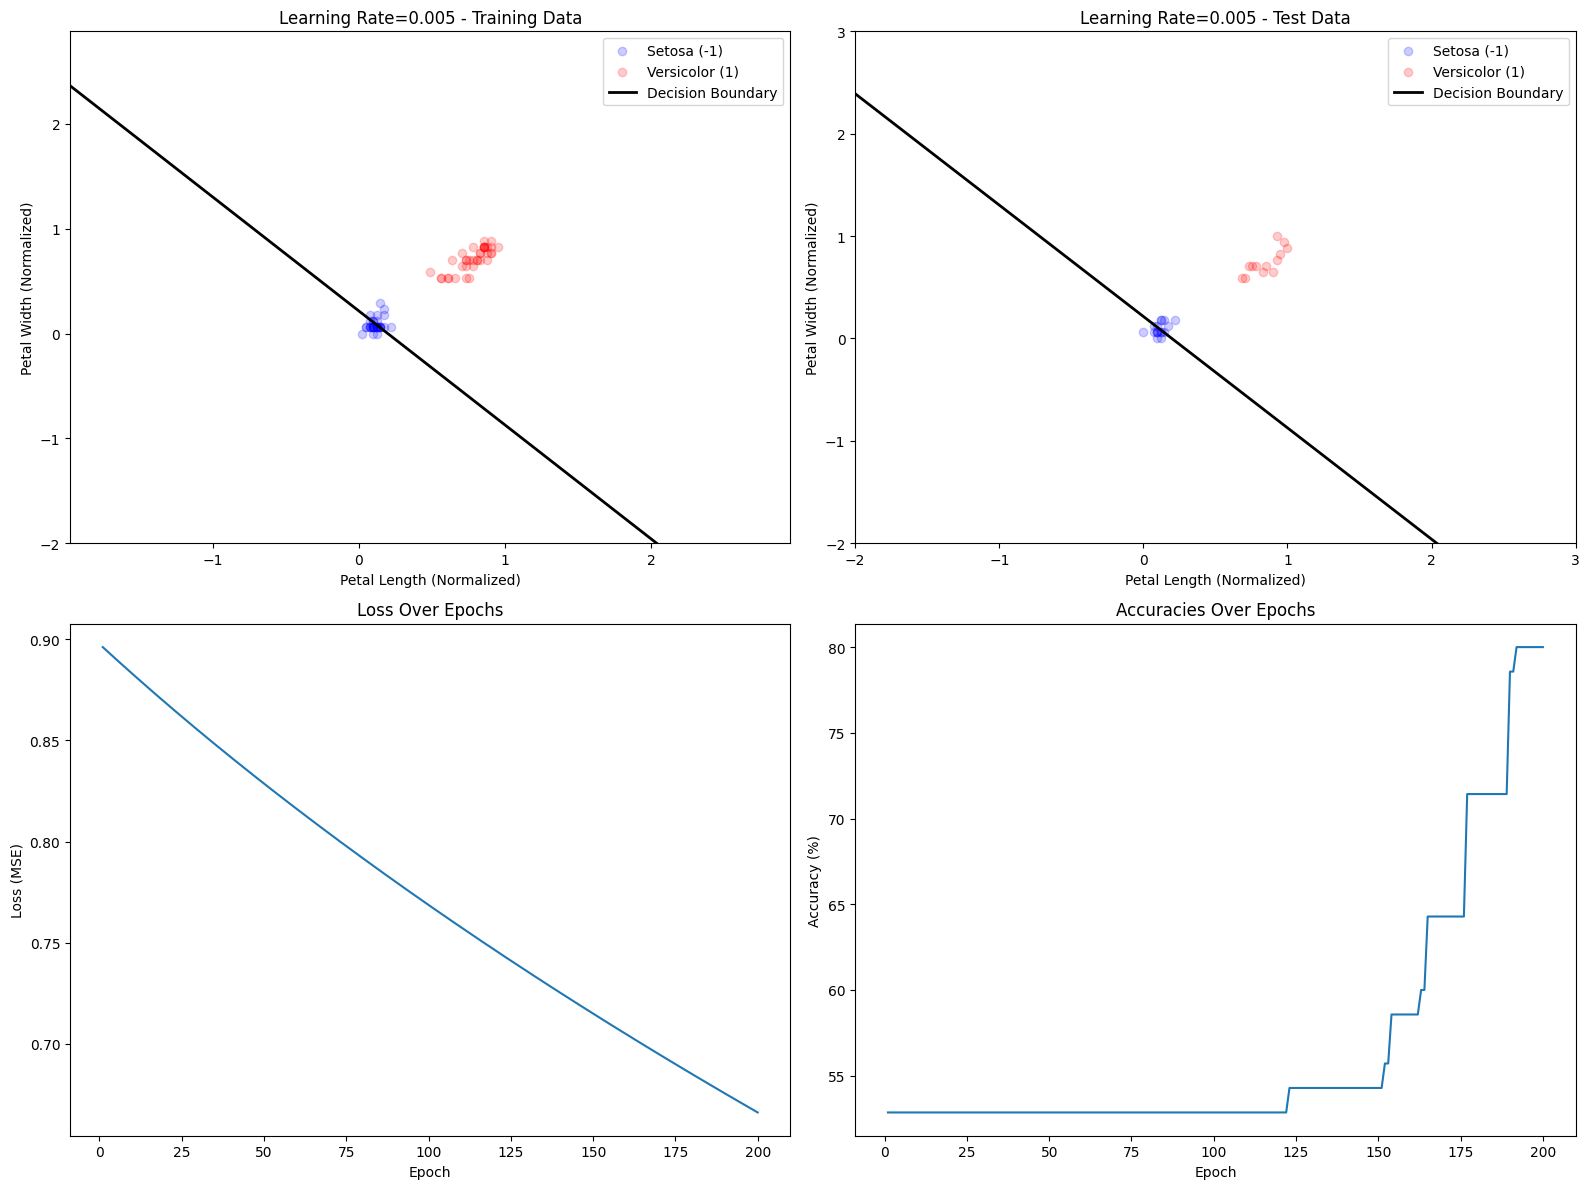

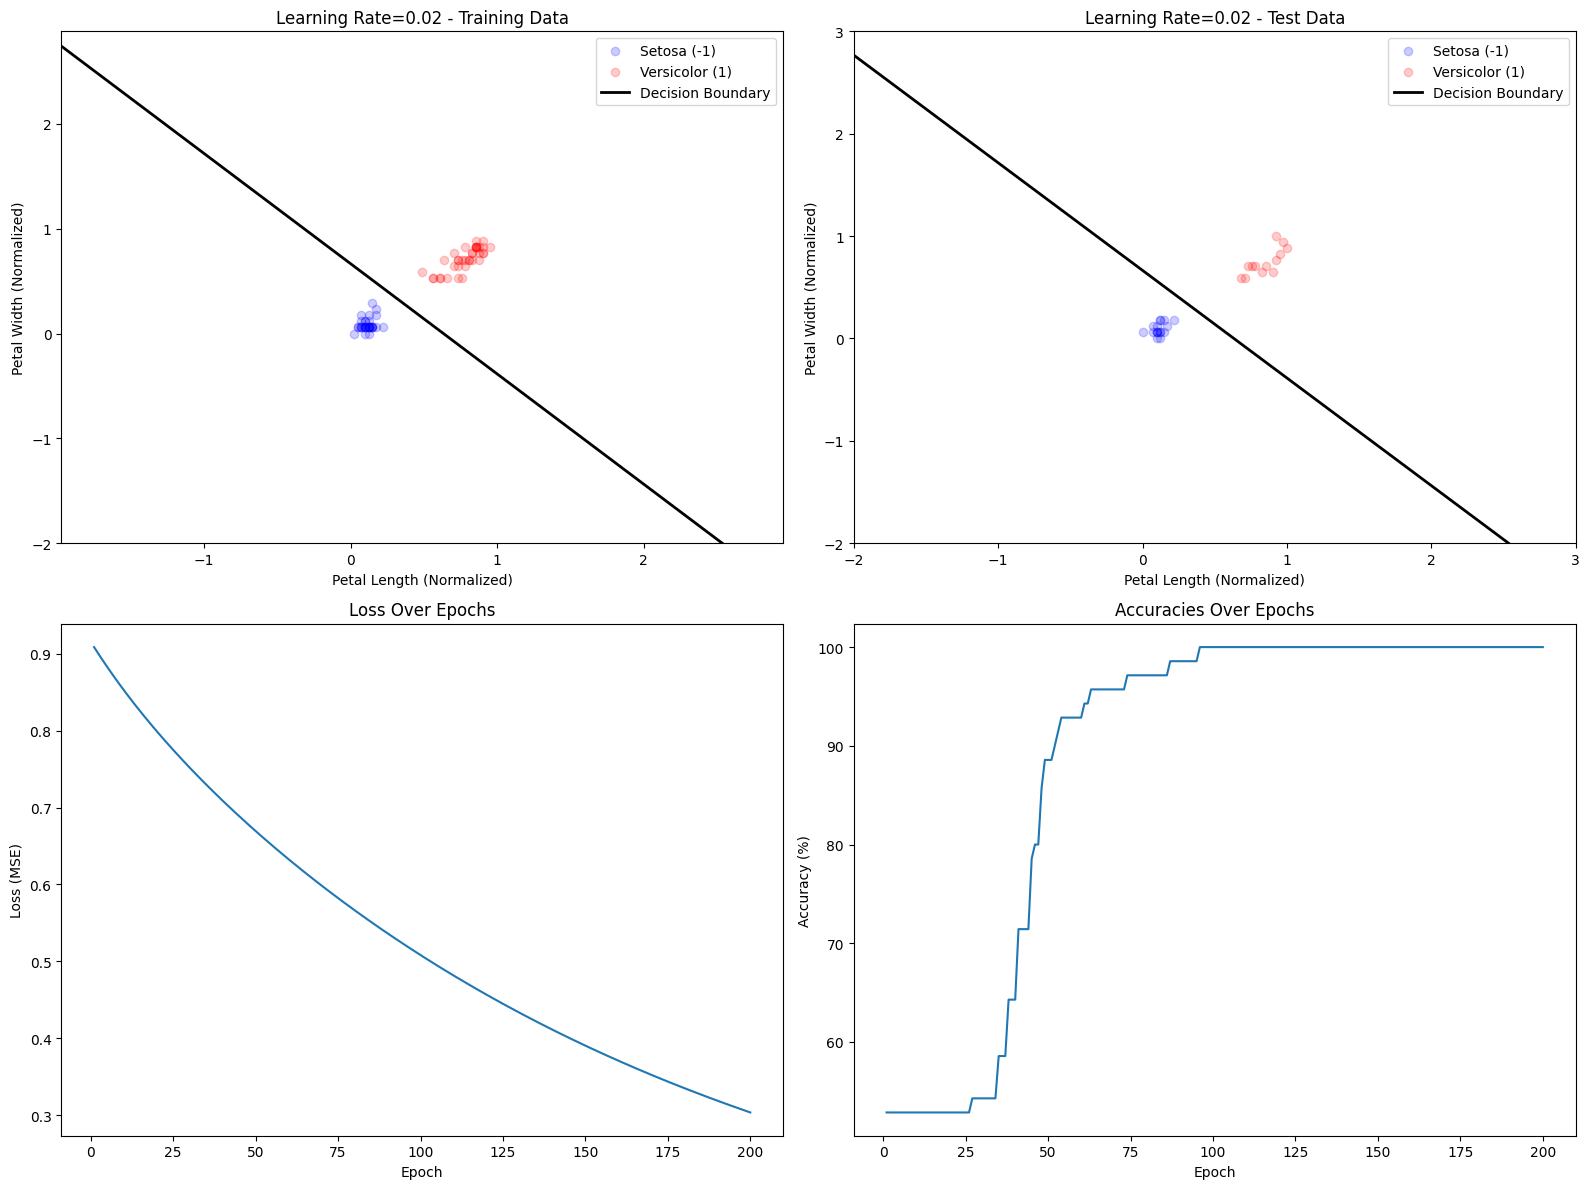

In [54]:
models = dict()
learning_rates = [0.001, 0.005, 0.02]
epochs = 200

for lr in learning_rates:
    model = Adaline(2, lr, epochs)
    model.fit(X_train, y_train)
    models[lr] = model

for lr, model in models.items():
    plot_decision_boundary_and_loss_accuracy(model, X_train, y_train, X_test, y_test, title=f'Learning Rate={lr}')